In [1]:
from random import seed

seed(1)

In [2]:
from random import uniform
from math import log, exp


def func(x, lmb):
    return 1 - exp(-lmb * x)


def generate(n, lmb):
    for _ in range(n):
        r = uniform(0, 1)

        yield -1 / lmb * log(r)

Математическое ожидание: 1.0007257908242517
Дисперсия: 1.032138762141413


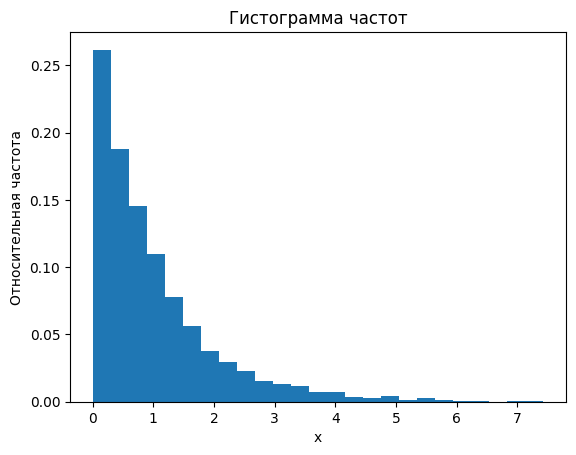

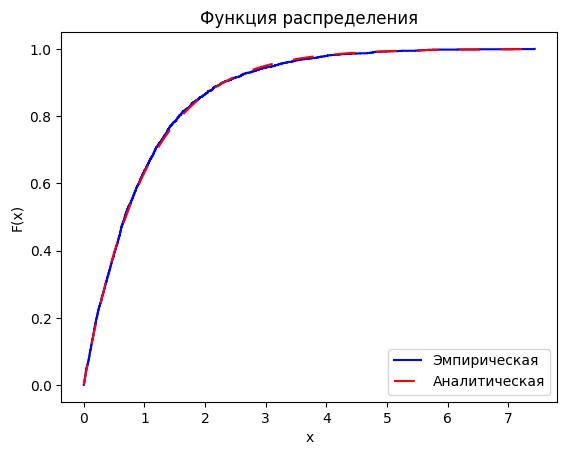

In [3]:
import matplotlib.pyplot as plt
import numpy as np

N = 2000
K = 25

lmb = 1

X = list(generate(N, lmb))

hist = [0] * K
h = (max(X) - min(X)) / K

for x in X:
    index = int((x - min(X)) / h)
    if index == K:
        index = K - 1
    hist[index] += 1

hist_norm = [v / N for v in hist]

X_sorted = sorted(X)
F = []

for i in range(N):
    F.append((i + 1) / N)

mean = sum(X) / N
second_moment = sum(x**2 for x in X) / N
variance = second_moment - mean**2

print("Математическое ожидание:", mean)
print("Дисперсия:", variance)

x_hist = [i * h for i in range(K)]

plt.figure()
plt.bar(x_hist, hist_norm, width=h, align="edge")
plt.title("Гистограмма частот")
plt.xlabel("x")
plt.ylabel("Относительная частота")
plt.show()

plt.figure()
plt.step(X_sorted, F, where="post", color="blue", label="Эмпирическая")

x_theor = np.linspace(X_sorted[0], X_sorted[-1], N)
y_theor = [func(x, lmb) for x in x_theor]
plt.plot(
    x_theor,
    y_theor,
    color="red",
    linestyle="--",
    dashes=(10, 10),
    label="Аналитическая",
)

plt.title("Функция распределения")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend()
plt.show()

In [4]:
import math


def kolmogorov(lambda_val, terms=10):
    s = 0
    for k in range(1, terms + 1):
        s += (-1) ** (k - 1) * math.exp(-2 * (k**2) * (lambda_val**2))
    return max(0, min(1, 2 * s))


D = 0

for i in range(N):
    dp = abs((i + 1) / N - func(X_sorted[i], lmb))
    dm = abs(func(X_sorted[i], lmb) - i / N)
    D = max(D, dp, dm)

lmb = D * N**0.5

print("D =", D)
print("λ =", lmb)
print("P(λ) =", kolmogorov(lmb))

D = 0.011799922236801597
λ = 0.5277085650139949
P(λ) = 0.943416133575303
